# ULA array demo

The digital signal received by the ULA elements after downconversion is performed is given by

$$x[n]e^{-2i \pi k f_c D \sin(\theta) / c},$$

where $k$ is the index of the specific array element, $f_c$ is the carrier frequency, $D$ is the distance between the elements (in meters), and $\theta$ is the angle of the arriving wavefront. However, working with this representation is difficult, particularly because of the high $f_c$ values. So we will perform some simplifications.

First, since $f_c = \dfrac{c}{\lambda}$, we can rewrite it as:

$$x[n]e^{-2i \pi k D \sin(\theta) / \lambda}.$$

Second, we can express the distance between the ULA elements in terms of the wavelength $\lambda$:

$$d = \dfrac{D}{\lambda}\ \Rightarrow$$
$$x[n]e^{-2i \pi k d \sin(\theta)}.$$

This expression allows us to build a model of ULA that doesn't depend on the carrier so that we deal only with the baseband signal which has much lower sampling rate.

Let's import the ULA model implementation that allows receiving a signal $x[n]$ and simulating its interaction with the array elements.

In [10]:
from ula import ULA
ula_instance = ULA(8, 0.5) # uniform linear array with 8 elements with D = λ / 2 => d = 0.5

When the ULA elements receive the signal at a non-zero angle, it arrives at each antenna at slightly different times. This results in each antenna getting a phase-shifted version of the original signal. We can introduce artificial delays in each antenna to counteract these phase shifts and figure out the direction of arrival (DOA) of the signal. To do this, we can scan across all available angles, apply the corresponding delays to the ULA elements, and measure the power of the sum of each received signal. The angle which yields the most power is the one at which the real signal arrives. This approach is conventional and is called "delay and sum" because this is literally what is happening to the signal at each antenna.

If the ULA is intended to receive multiple signals, an adaptive DOA such as MUSIC (MUltiple SIgnal Classification) may be employed. MUSIC determines the angles of arrival as follows:

$$\theta = \argmax \left( \dfrac{1}{s^H V_n V^H_n s} \right),$$

where $V$ is the "noise subspace" constructed from the eigenvalues of the steered signal's covariance matrix and $s$ is the steering vector.

Let's now create a test signal, which is a simple rectangular pulse, have the ULA receive it at some angle, and apply both delay-and-sum and MUSIC to estimate the angle of arrival.

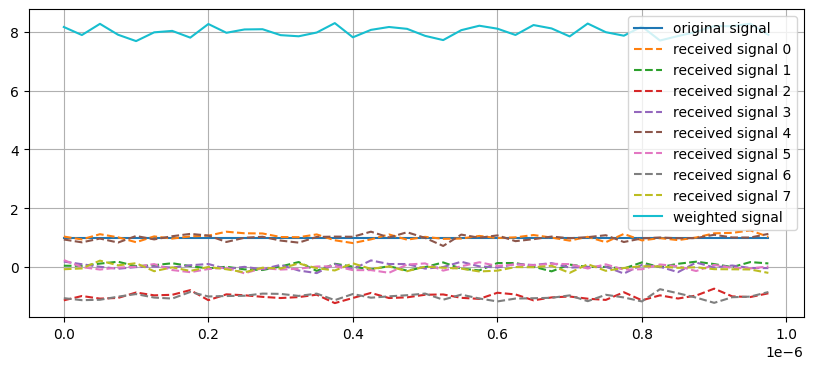

In [11]:
import numpy as np

sampling_rate = 40e6 # 40 MHz baseband after downconversion
pulse_duration = 1e-6 # 1 microsecond
N = int(sampling_rate * pulse_duration)
t = np.arange(N) / sampling_rate
θ = np.radians(30)
signal = np.exp(2j * np.pi * 0 * t) # a rectangular pulse is just a wave with the frequency of 0, the generalized form is easier to change for debugging purposes

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(t, signal.real, label="original signal")

SNR_dB = 20
SNR = 10.0**(SNR_dB/10.0)

from signal_utils import add_noise
steered_signal = np.array([
    add_noise(steered_signal, SNR)
    for steered_signal in ula_instance.steer_signal(signal, θ)
])

for i, x in enumerate(steered_signal):
    plt.plot(t, x.real, label=f"received signal {i}", linestyle="--")

weighted_signal = ula_instance.delay_and_sum(steered_signal, θ)
plt.plot(t, weighted_signal.real, label=f"weighted signal")
plt.legend()
plt.grid()
plt.show()

When the ULA elements receive the signal at a non-zero angle, it arrives at each antenna at slightly different times. This results in each antenna getting a phase-shifted version of the original signal. We can introduce artificial delays in each antenna to counteract these phase shifts and figure out the direction of arrival (DOA) of the signal. To do this, we can scan across all available angles, apply the corresponding delays to the ULA elements, and measure the power of the sum of each received signal. The angle which yields the most power is the one at which the real signal arrives. This approach is conventional and is called "delay and sum" because this is literally what is happening to the signal at each antenna.

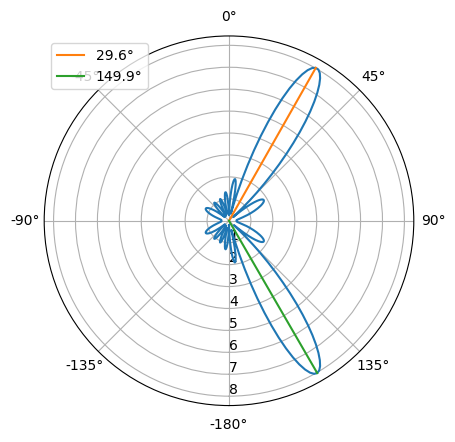

In [12]:
Θ, p = ula_instance.get_θ_scan(steered_signal)

estimated_θs = []

# print(estimated_θ * 180 / np.pi)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(Θ, p)

from ula import power
threshold = 0.9 * power(signal) * ula_instance.N
for i in range(1, len(p)-1):
    if p[i-1] < p[i] and p[i] > p[i+1] and p[i] > threshold:
        ax.plot([Θ[i], Θ[i]], [0, p[i]], label=f"{(Θ[i] / np.pi * 180).round(1)}°")

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(180)
ax.set_thetamin(-180) # only show top half
ax.set_thetamax(180)
plt.legend()
plt.show()

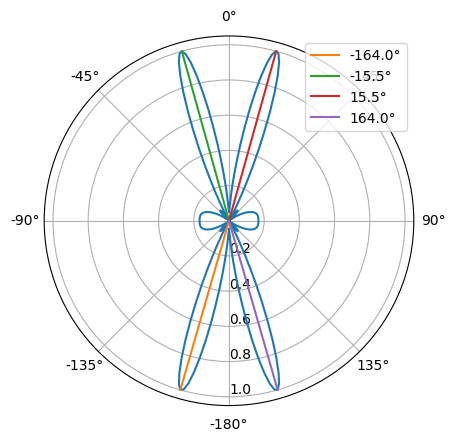

In [13]:
Θ, p_music = ula_instance.music(steered_signal, 1)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(Θ, p_music)

threshold = 0.5
for i in range(1, len(p)-1):
    if p_music[i-1] < p_music[i] and p_music[i] > p_music[i+1] and p_music[i] > threshold:
        θ_degrees = Θ[i] / np.pi * 180
        ax.plot([Θ[i], Θ[i]], [0, p_music[i]], label=f"{round(θ_degrees,1)}°")

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(180)
ax.set_thetamin(-180) # only show top half
ax.set_thetamax(180)
plt.legend()
plt.show()